# RAG Agent with Routing and Document Grading

In this notebook we'll build an **Agentic RAG** system that:

1. **Routes** questions to either a vectorstore or web search
2. **Retrieves** documents from a Chroma vectorstore
3. **Grades** retrieved documents for relevance
4. **Falls back** to web search if documents aren't relevant
5. **Generates** an answer using the retrieved context

This is a simplified version of the [Adaptive RAG](https://arxiv.org/abs/2403.14403) pattern.

**Model choice**: Uses OpenAI by default, with an option to switch to a local model (gemma4 via Ollama).

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain langchain-community langchain-openai langchain-ollama langchain-text-splitters langgraph chromadb tiktoken tavily-python beautifulsoup4 pydantic

In [32]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

# Optional: Enable LangSmith tracing
# os.environ["LANGSMITH_TRACING"] = "true"
# _set_env("LANGSMITH_API_KEY")

---
## Step 1: Load Documents and Create Retriever

We'll load a few blog posts about LLM agents, split them into chunks, and index them in a Chroma vectorstore.

In [33]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)
print(f"Split into {len(doc_splits)} chunks")

Split into 191 chunks


In [34]:
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-agent",
    embedding=OpenAIEmbeddings(),
)

# Alternative: Local embeddings with Ollama
# from langchain_ollama import OllamaEmbeddings
# vectorstore = Chroma.from_documents(
#     documents=doc_splits,
#     collection_name="rag-agent-local",
#     embedding=OllamaEmbeddings(model="nomic-embed-text"),
# )

retriever = vectorstore.as_retriever()

# Quick test
retriever.invoke("What are types of agent memory?")

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consi

---
## Step 2: Configure the LLM

Choose between OpenAI (cloud) or Ollama (local). Toggle by uncommenting the preferred option.

In [39]:
# Option A: OpenAI (default)
from langchain.chat_models import init_chat_model
llm = init_chat_model(model="gpt-5.4", temperature=0)

# Option B: Local with Ollama (uncomment to use)
# llm = init_chat_model(model="ollama:gemma4", temperature=0)

In [ ]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(k=3)
# web_search_tool.invoke("What are the latest developments in LangGraph?")   

---
## Step 3: Router — Route Questions to the Right Source

The router uses structured output to decide: should this question go to the **vectorstore** or to **web search**?

In [40]:
from pydantic import BaseModel, Field
from typing import Literal

class RouteDecision(BaseModel):
    """Route a question to the most relevant datasource."""
    datasource: Literal["vectorstore", "websearch"] = Field(
        description="Route to 'vectorstore' for questions about agents, prompt engineering, and adversarial attacks. Route to 'websearch' for current events or other topics."
    )

llm_router = llm.with_structured_output(RouteDecision)

# Test: should route to vectorstore
result = llm_router.invoke("What are the types of agent memory?")
print(f"Route: {result.datasource}")

# Test: should route to websearch
result = llm_router.invoke("What is going on at the AI Engineer Conference in London april 8th?")
print(f"Route: {result.datasource}")

Route: vectorstore
Route: websearch


---
## Step 4: Document Grader — Grade Retrieved Documents

After retrieval, we check if each document is actually relevant to the question. If not, we fall back to web search.

In [41]:
class GradeDocument(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: Literal["yes", "no"] = Field(
        description="Document is relevant to the question: 'yes' or 'no'"
    )

llm_grader = llm.with_structured_output(GradeDocument)

# Test
test_doc = retriever.invoke("agent memory")[0]
result = llm_grader.invoke(
    f"Document: {test_doc.page_content}\n\nQuestion: What are types of agent memory?\n\nIs this document relevant?"
)
print(f"Relevance: {result.binary_score}")

Relevance: yes


---
## Step 5: Define Graph State and Nodes

Now we define the graph state and all node functions.

In [42]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage

class GraphState(TypedDict):
    question: str
    generation: str
    web_search: str
    documents: List[str]

In [46]:
# --- Node Functions ---

def retrieve(state):
    """Retrieve documents from vectorstore."""
    print("---RETRIEVE---")
    documents = retriever.invoke(state["question"])
    return {"documents": documents}


def generate(state):
    """Generate answer using retrieved documents as context."""
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    docs_text = "\n\n".join(doc.page_content for doc in documents)
    
    prompt = f"""You are an assistant for question-answering tasks. Use the following context to answer the question concisely.
If you don't know the answer, say so.

Question: {question}
Context: {docs_text}
Answer:"""
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"generation": response.content}


def grade_documents(state):
    """Grade each retrieved document for relevance. Flag for web search if any are irrelevant."""
    print("---GRADE DOCUMENTS---")
    question = state["question"]
    documents = state["documents"]
    
    filtered_docs = []
    web_search = "No"
    
    for doc in documents:
        result = llm_grader.invoke(
            f"Document: {doc.page_content}\n\nQuestion: {question}\n\nIs this document relevant?"
        )
        if result.binary_score == "yes":
            print("  -> RELEVANT")
            filtered_docs.append(doc)
        else:
            print("  -> NOT RELEVANT")
            web_search = "Yes"
    
    return {"documents": filtered_docs, "web_search": web_search}


def web_search(state):
    """Run web search and append results to documents."""
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state.get("documents", [])
    
    results = web_search_tool.invoke({"query": question})
    web_content = "\n".join(d["content"] for d in results["results"])
    documents.append(Document(page_content=web_content))
    return {"documents": documents}

In [47]:
# --- Edge Functions (routing logic) ---

def route_question(state):
    """Route question to vectorstore or web search."""
    print("---ROUTE QUESTION---")
    result = llm_router.invoke(state["question"])
    print(f"  -> {result.datasource}")
    return result.datasource


def decide_to_generate(state):
    """After grading, decide: generate answer or fall back to web search."""
    if state["web_search"] == "Yes":
        print("---DECISION: WEB SEARCH (some docs not relevant)---")
        return "websearch"
    print("---DECISION: GENERATE---")
    return "generate"

---
## Step 6: Build and Compile the Graph

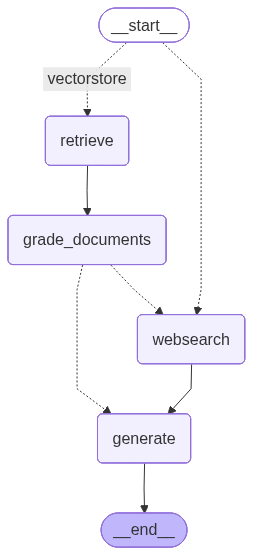

In [48]:
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("websearch", web_search)

# Entry point: route question to vectorstore or websearch
workflow.set_conditional_entry_point(
    route_question,
    {
        "vectorstore": "retrieve",
        "websearch": "websearch",
    },
)

# After retrieval, grade the documents
workflow.add_edge("retrieve", "grade_documents")

# After grading, either generate or fall back to web search
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "websearch": "websearch",
        "generate": "generate",
    },
)

# Web search always leads to generate
workflow.add_edge("websearch", "generate")

# Generate is the final step
workflow.add_edge("generate", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

---
## Step 7: Test the Agent

In [49]:
# Test 1: Question about agents → should route to vectorstore
result = graph.invoke({"question": "What are the types of agent memory?"})
print("\n=== ANSWER ===")
print(result["generation"])

---ROUTE QUESTION---
  -> vectorstore
---RETRIEVE---
---GRADE DOCUMENTS---
  -> RELEVANT
  -> RELEVANT
  -> RELEVANT
  -> RELEVANT
---DECISION: GENERATE---
---GENERATE---

=== ANSWER ===
The types of agent memory mentioned are:

- Sensory memory
- Short-term memory
- Long-term memory


In [50]:
# Test 2: Current events → should route to web search
result = graph.invoke({"question": "What are the latest developments in LangGraph?"})
print("\n=== ANSWER ===")
print(result["generation"])

---ROUTE QUESTION---
  -> websearch
---WEB SEARCH---
---GENERATE---

=== ANSWER ===
The latest developments mentioned are:

- LangGraph v1 is a stability-focused release for the agent runtime.
- It keeps the core graph APIs and execution model unchanged.
- It improves type safety and documentation.
- Since release 1.1.4, updates include:
  - `prebuilt 1.0.9` and `langgraph 1.1.5` (#7401)
  - improved runtime execution information (#7363)
- LangGraph 1.0 reached a stable release in 2025.
- There is also mention of LangGraph v0.2 (2026) with a full breakdown of features, breaking changes, code updates, and migration tips.

So, the newest concrete updates in the provided context are the `langgraph 1.1.5` release and the runtime enhancement with more execution information.


---
## Summary

| Component | Purpose |
|-----------|--------|
| **Router** | Classifies questions → vectorstore or web search |
| **Retriever** | Fetches relevant docs from Chroma |
| **Grader** | Filters irrelevant docs, triggers web search fallback |
| **Web Search** | Tavily search as backup for missing/irrelevant docs |
| **Generator** | Produces final answer from context |

### Graph Flow
```
START → route_question → {vectorstore: retrieve, websearch: websearch}
retrieve → grade_documents → {generate, websearch}
websearch → generate → END
```

### Local Model Option
To use a local model instead of OpenAI, uncomment the Ollama lines in Steps 2 and 5:
```python
# Make sure to pull the model first: ollama pull gemma4
from langchain_ollama import ChatOllama
llm = ChatOllama(model=\"gemma4\", temperature=0)
```

For the advanced version with hallucination grading and retry loops, see `extra-notebooks/4.0-local-agent-llama32.ipynb`.